# Yield Simulator for W2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator
from types import SimpleNamespace
import os

Running assembly yield simulator over 10 wafers...
Verbose mode enabled: Tracking failure reasons for each die.
Simulating stack 1/1 interface 1/4: Memory_DRAM_0_From_TSV_Interconnect_Die...


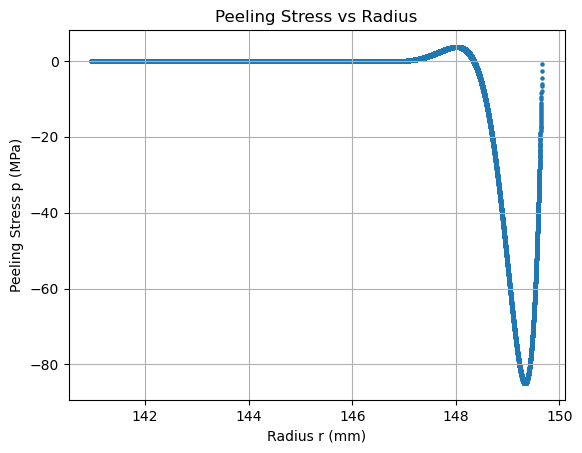

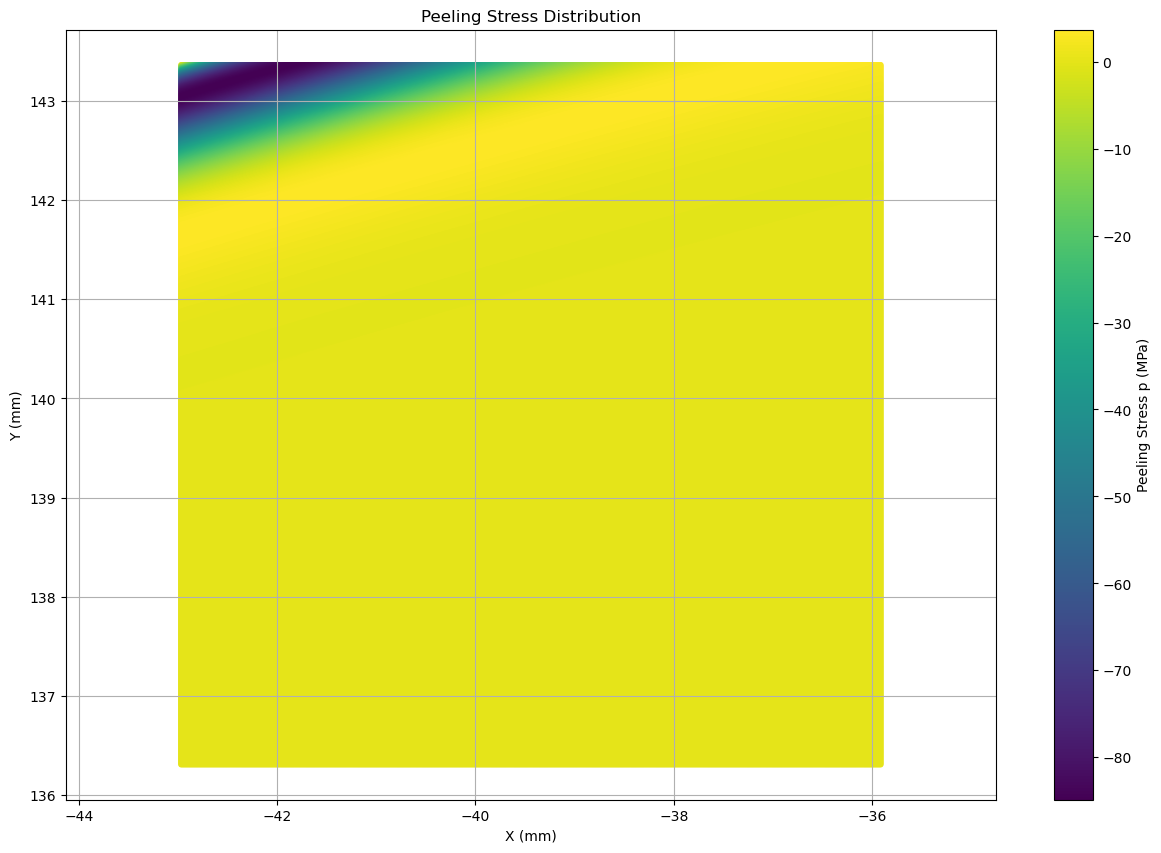

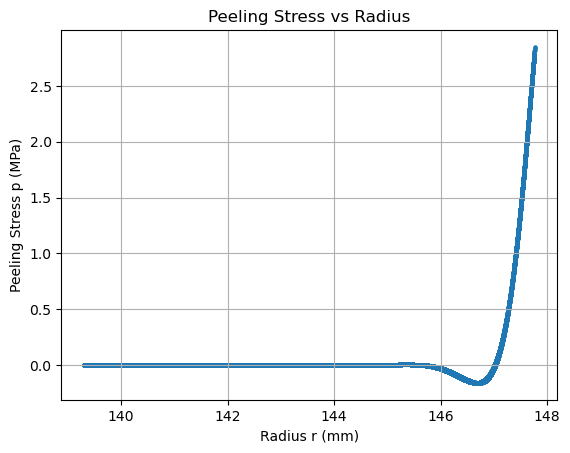

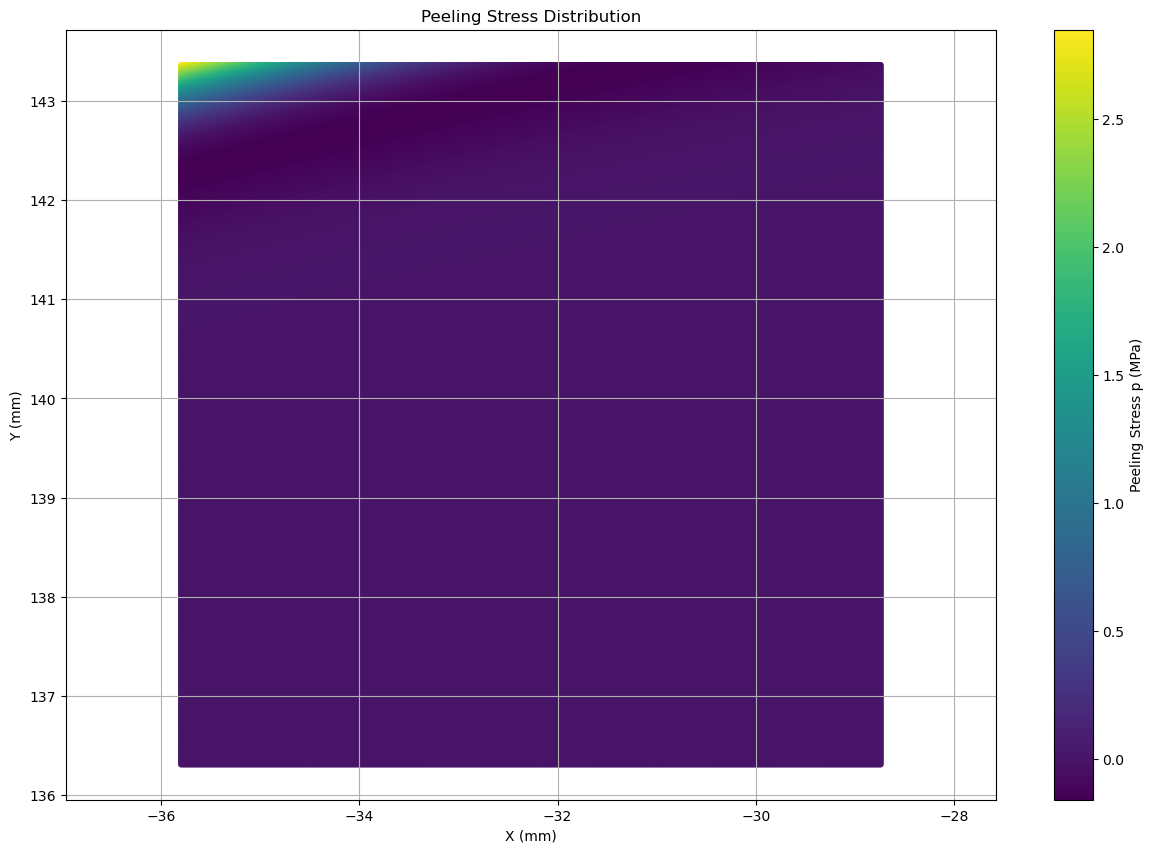

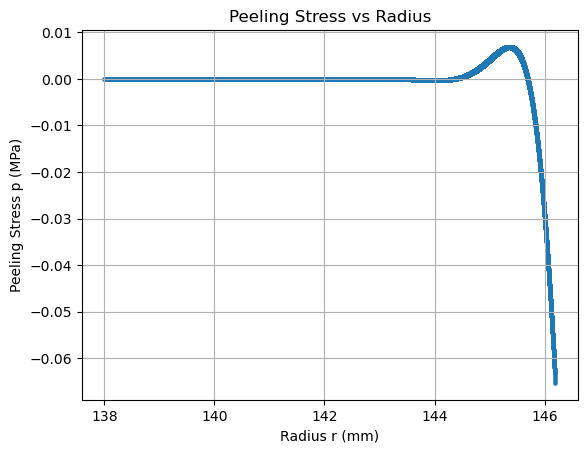

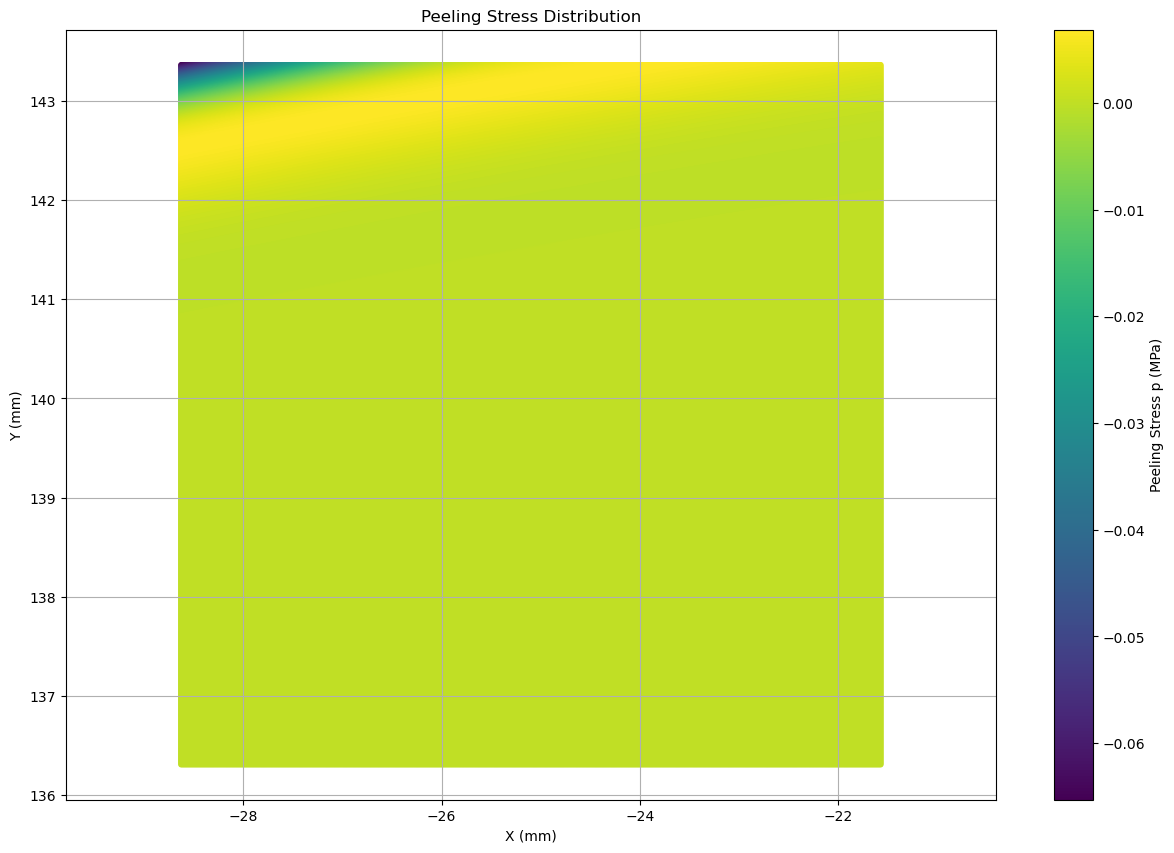

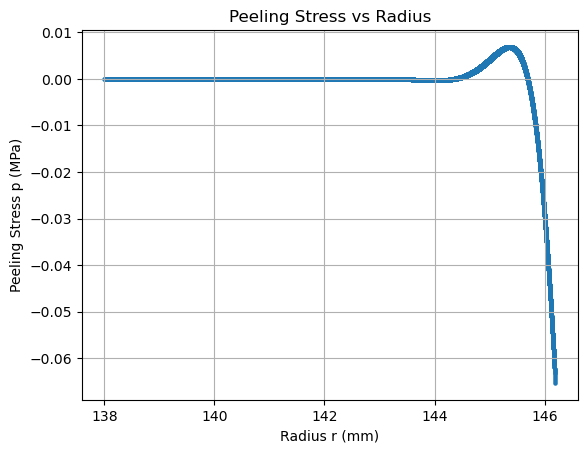

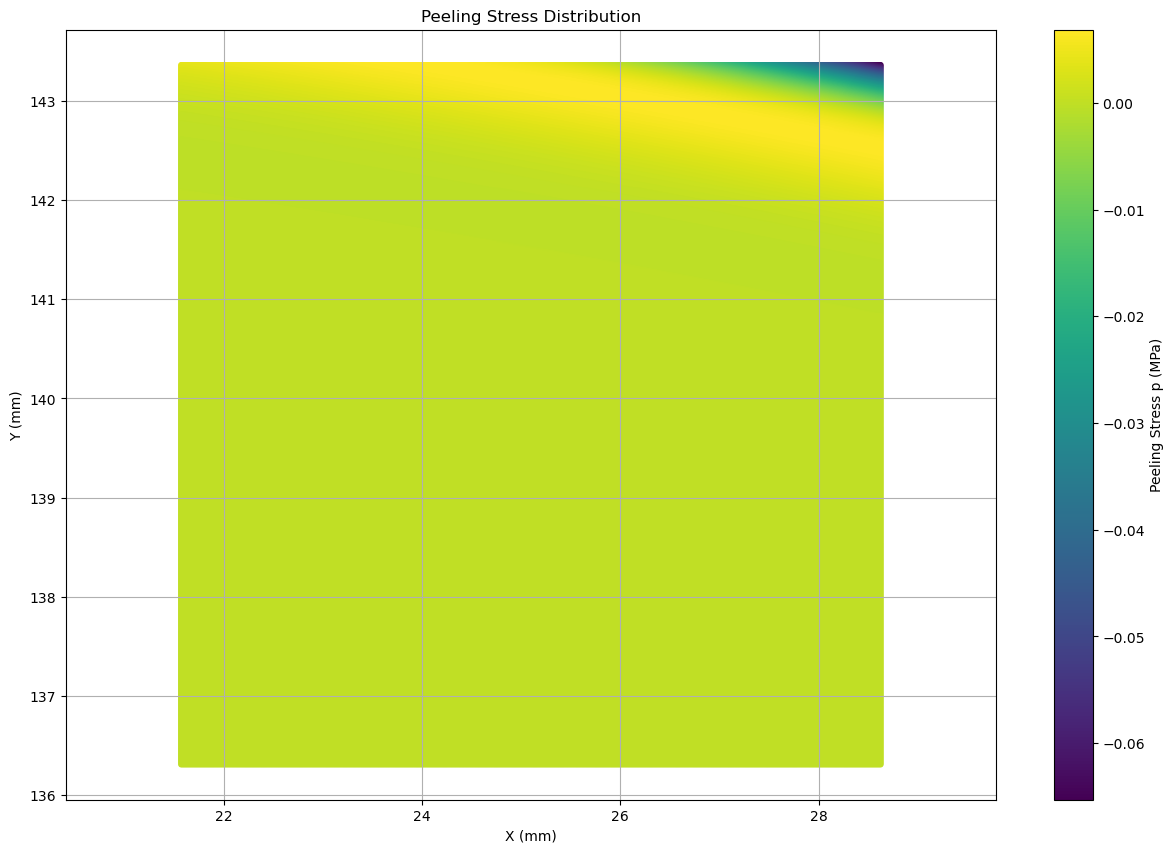

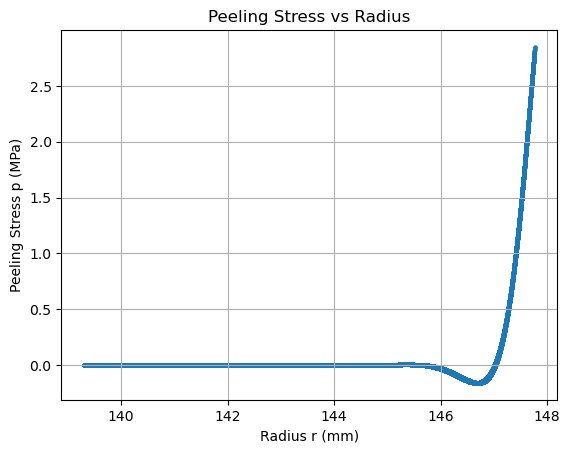

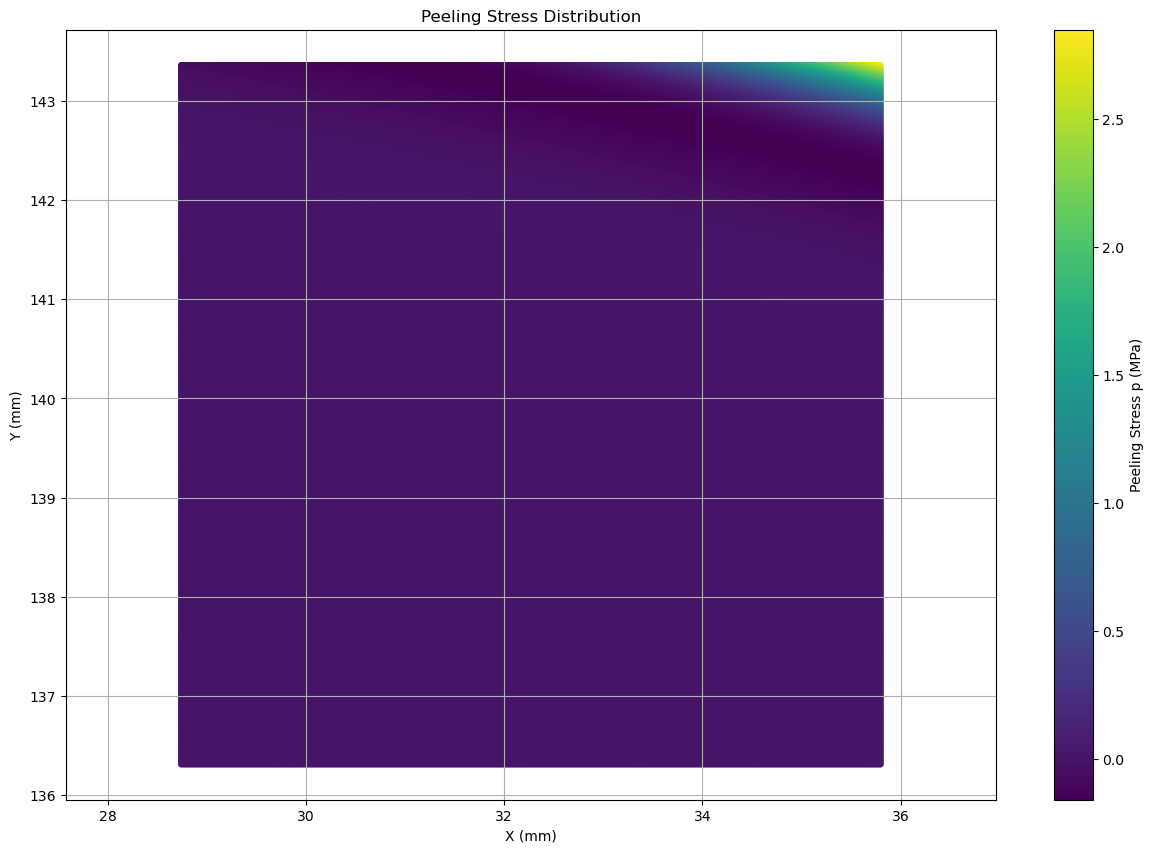

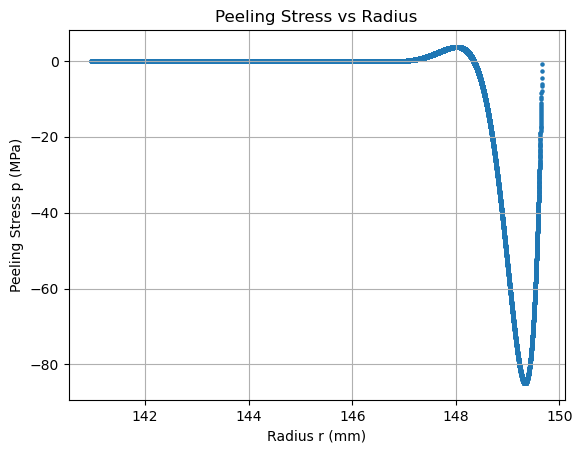

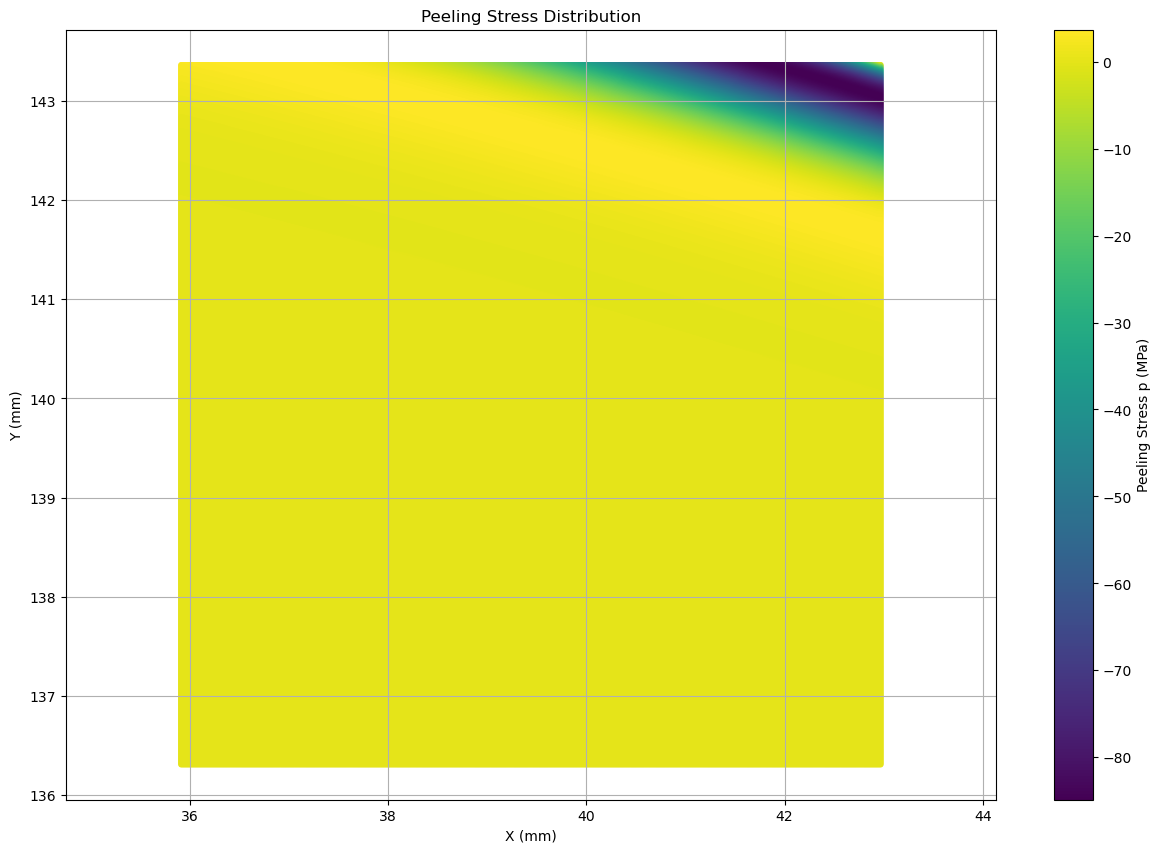

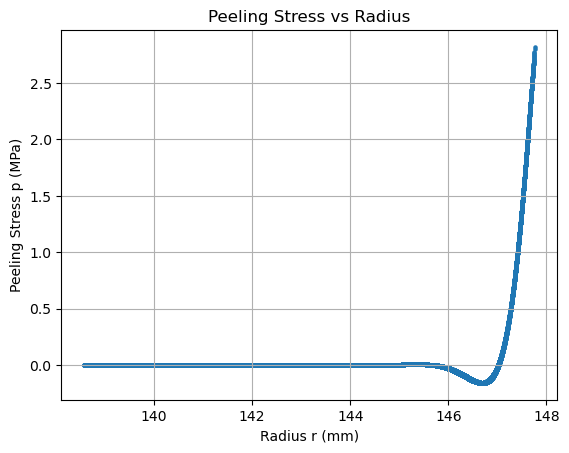

KeyboardInterrupt: 

In [5]:
# Notebook-friendly run (equivalent to the CLI command)
args = SimpleNamespace(
    config="configs/design_6/design_6.yaml",
    mode="w2w_simulation",
    ds_name="design_6",
    ds_dir="input/design_6",
    plot=False,
    verbose=True,
    debug=False,
 )

input_ds_dir = args.ds_dir
_3dbv_path = os.path.join(input_ds_dir, "generated_chiplet_definitions.3dbv")
_3dbx_path = os.path.join(input_ds_dir, "generated_stack_config.3dbx")
cfg_skeleton = OmegaConf.load(args.config)[args.mode]

cfg_dict = get_config_dict(
    cfg_folder=args.config.rsplit("/", 1)[0],
    cfg_skeleton=cfg_skeleton,
    ds_name=args.ds_name,
    input_ds_dir=input_ds_dir,
    _3dbv_path=_3dbv_path,
    _3dbx_path=_3dbx_path,
    mode=args.mode,
    debug=args.debug,
 )

for cfg in cfg_dict.values():
    cfg.plot_flag = args.plot
    cfg.verbose = args.verbose
    output_path = os.path.join(cfg.OUTPUT_DIR, args.ds_name, cfg.INTERFACE)
    os.makedirs(output_path, exist_ok=True)

pad_bitmap_collection_dict = {}
for interface, cfg in cfg_dict.items():
    bmap_path = os.path.join(input_ds_dir, f"{cfg.INTERFACE}.bmap")
    criticality_path = os.path.join(input_ds_dir, f"{cfg.INTERFACE}_criticality.txt")
    pad_bitmap_collection_dict[interface] = convert_3dblox_to_pad_bitmap(
        cfg=cfg,
        _bmap_path=bmap_path,
        criticality_path=criticality_path,
        pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN,
    )

print(f"Running assembly yield simulator over {cfg_skeleton.NUM_WAFER_STACKS} wafers...")
start_time = time.time()
stack_assembly_yield, _ = Assembly_Yield_Simulator(
    input_args=vars(args),
    cfg_skeleton=cfg_skeleton,
    cfg_dict=cfg_dict,
    pad_bitmap_collection_dict=pad_bitmap_collection_dict,
 )

print(f"Yield simulation results for {args.ds_name}: {stack_assembly_yield}")
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))